R_L(\Omega),U(V),I(mA)
100,6.67,65.9
200,7.27,35.9
300,7.49,24.8
500,7.68,15.3
800,7.79,9.57
inf,7.99,0.00

Fitted line: U = -19.9732 * I + 7.9859


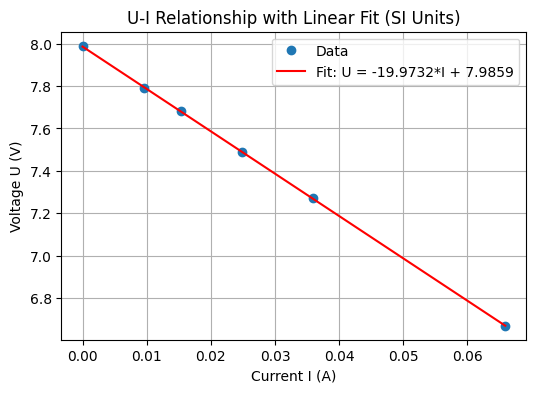

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
import numpy as np

# Prepare data (SI units: I in A, U in V, R_L in Ohm)
data = '''R_L(Ohm),U(V),I(A)
100,6.67,0.0659
200,7.27,0.0359
300,7.49,0.0248
500,7.68,0.0153
800,7.79,0.00957
inf,7.99,0.00'''
df = pd.read_csv(StringIO(data))

# Least squares linear fit: U = a * I + b
I = df['I(A)'].values
U = df['U(V)'].values
A = np.vstack([I, np.ones(len(I))]).T
a, b = np.linalg.lstsq(A, U, rcond=None)[0]
print(f"Fitted line: U = {a:.4f} * I + {b:.4f}")

# Plot U vs I and fitted line
plt.figure(figsize=(6,4))
plt.plot(I, U, 'o', label='Data')
plt.plot(I, a*I + b, 'r-', label=f'Fit: U = {a:.4f}*I + {b:.4f}')
plt.xlabel('Current I (A)')
plt.ylabel('Voltage U (V)')
plt.title('U-I Relationship with Linear Fit (SI Units)')
plt.legend()
plt.grid(True)
plt.savefig('ui_relationship.png')
plt.show()